Set the Device (GPU)

In [8]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


train + val + test

In [9]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

random.seed(42)

SOURCE = "/kaggle/input/datasets/rtislam/chest-xray/chest_xray"
DEST = "/kaggle/working/chest_xray_split"

os.makedirs(DEST, exist_ok=True)

Create Class

In [11]:
classes = ["NORMAL", "BACTERIAL", "VIRAL"]

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST, split, cls), exist_ok=True)

Label All Images

In [12]:
all_images = []

for split in ["train", "val", "test"]:

    # NORMAL 
    normal_dir = os.path.join(SOURCE, split, "NORMAL")

    if os.path.exists(normal_dir):
        for f in os.listdir(normal_dir):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                all_images.append((os.path.join(normal_dir, f), "NORMAL"))

    # PNEUMONIA
    pneumonia_dir = os.path.join(SOURCE, split, "PNEUMONIA")

    if os.path.exists(pneumonia_dir):
        for f in os.listdir(pneumonia_dir):

            name = f.lower()

            if "bacteria" in name:
                label = "BACTERIAL"

            elif "virus" in name:
                label = "VIRAL"

            else:
                continue

            all_images.append((os.path.join(pneumonia_dir, f), label))

print("Total Images:", len(all_images))

Total Images: 5856


Split Dataset

In [14]:
labels = [label for _, label in all_images]

train_data, temp_data = train_test_split(
    all_images,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

temp_labels = [label for _, label in temp_data]

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

Copy Images to Split Folders

In [15]:
def copy_images(data, split):

    for img_path, label in data:

        dst = os.path.join(
            DEST,
            split,
            label,
            os.path.basename(img_path)
        )

        shutil.copy(img_path, dst)

copy_images(train_data, "train")
copy_images(val_data, "val")
copy_images(test_data, "test")

Verify Dataset Split

In [16]:
for split in ["train", "val", "test"]:

    print("\n", split.upper())

    total = 0

    for cls in classes:

        folder = os.path.join(DEST, split, cls)

        count = len(os.listdir(folder))

        total += count

        print(f"{cls}: {count}")

    print("Total:", total)


 TRAIN
NORMAL: 1266
BACTERIAL: 2224
VIRAL: 1194
Total: 4684

 VAL
NORMAL: 159
BACTERIAL: 278
VIRAL: 149
Total: 586

 TEST
NORMAL: 158
BACTERIAL: 278
VIRAL: 150
Total: 586


Import Libraries

In [7]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)



Dataset Paths

In [17]:
train_dir = "/kaggle/working/chest_xray_split/train"
val_dir   = "/kaggle/working/chest_xray_split/val"
test_dir  = "/kaggle/working/chest_xray_split/test"

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/working/chest_xray_split/train
/kaggle/working/chest_xray_split/val
/kaggle/working/chest_xray_split/test


Data Augmentation & Image Transforms

In [18]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Create Dataset and DataLoader

In [19]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))
print("Testing Images:", len(test_dataset))

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Classes: ['BACTERIAL', 'NORMAL', 'VIRAL']
Training Images: 4684
Validation Images: 586
Testing Images: 586


Build CNN Model

In [20]:
class PneumoniaCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PneumoniaCNN(num_classes=3).to(device)

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

Loss Function, Optimizer & Scheduler

Trainable Parameters

In [21]:
model=PneumoniaCNN().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(total_params)

26146051


In [43]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print("Loss Function :", criterion)
print("Optimizer :", optimizer)
print("Scheduler :", scheduler)

Loss Function : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler : <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x7cd90a3004d0>


Training & Validation Loop

In [44]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):

    #Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    #Validation

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader.dataset)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_pneumonia_model.pth")

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print("-" * 50)

print("Training Finished!")

Epoch [1/30]
Train Loss: 1.3312 | Train Acc: 56.23%
Val Loss:   0.7243 | Val Acc:   65.87%
--------------------------------------------------
Epoch [2/30]
Train Loss: 0.7753 | Train Acc: 64.43%
Val Loss:   0.6614 | Val Acc:   68.94%
--------------------------------------------------
Epoch [3/30]
Train Loss: 0.7115 | Train Acc: 67.70%
Val Loss:   0.6273 | Val Acc:   68.77%
--------------------------------------------------
Epoch [4/30]
Train Loss: 0.6756 | Train Acc: 69.21%
Val Loss:   0.5854 | Val Acc:   70.14%
--------------------------------------------------
Epoch [5/30]
Train Loss: 0.6445 | Train Acc: 71.09%
Val Loss:   0.5602 | Val Acc:   73.89%
--------------------------------------------------
Epoch [6/30]
Train Loss: 0.6127 | Train Acc: 72.95%
Val Loss:   0.5927 | Val Acc:   75.94%
--------------------------------------------------
Epoch [7/30]
Train Loss: 0.6320 | Train Acc: 72.69%
Val Loss:   0.5459 | Val Acc:   74.57%
--------------------------------------------------
Epoch 

Test Evaluation (Accuracy, Classification Report & Confusion Matrix)

Test Accuracy: 78.67%

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.75      0.90      0.82       278
   BACTERIAL       0.86      0.97      0.91       158
       VIRAL       0.75      0.38      0.50       150

    accuracy                           0.79       586
   macro avg       0.79      0.75      0.75       586
weighted avg       0.78      0.79      0.77       586



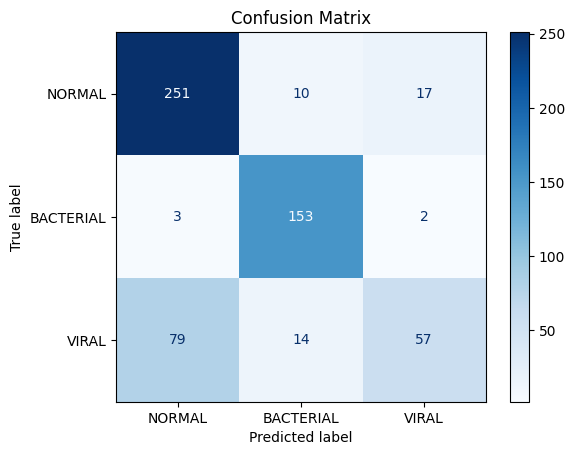

In [45]:



from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load best model
model.load_state_dict(torch.load("best_pneumonia_model.pth"))
model.eval()

all_labels = []
all_predictions = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["NORMAL", "BACTERIAL", "VIRAL"]
))

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["NORMAL", "BACTERIAL", "VIRAL"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Accuracy & Loss Graphs

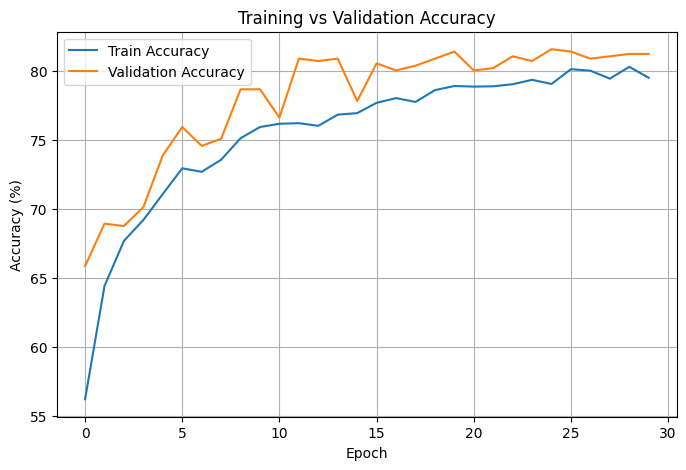

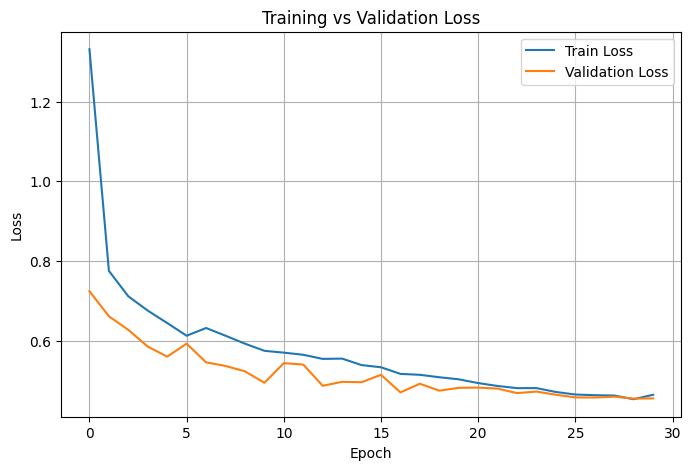

In [46]:


# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()